In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix)
# Model persistence
import pickle
# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/umarkhan360/week-3/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Encode categorical variables
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract',
'PaperlessBilling', 'PaymentMethod']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
# Separate features and target
X = df_encoded.drop(['customerID', 'Churn'], axis=1)
y = df_encoded['Churn']
# Split data
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 5634
Test samples: 1409


In [3]:
# Baseline Random Forest (from Week 2)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
# Evaluate
y_pred_baseline = rf_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f'Baseline Random Forest Accuracy: {baseline_accuracy:.4f}')
print('\nBaseline Classification Report:')
print(classification_report(y_test, y_pred_baseline))


Baseline Random Forest Accuracy: 0.7864

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



Cross-Validation Results:
Scores for each fold: [0.8065661  0.79414374 0.78793256 0.77284827 0.77975133]
Mean CV Score: 0.7882
Standard Deviation: 0.0117


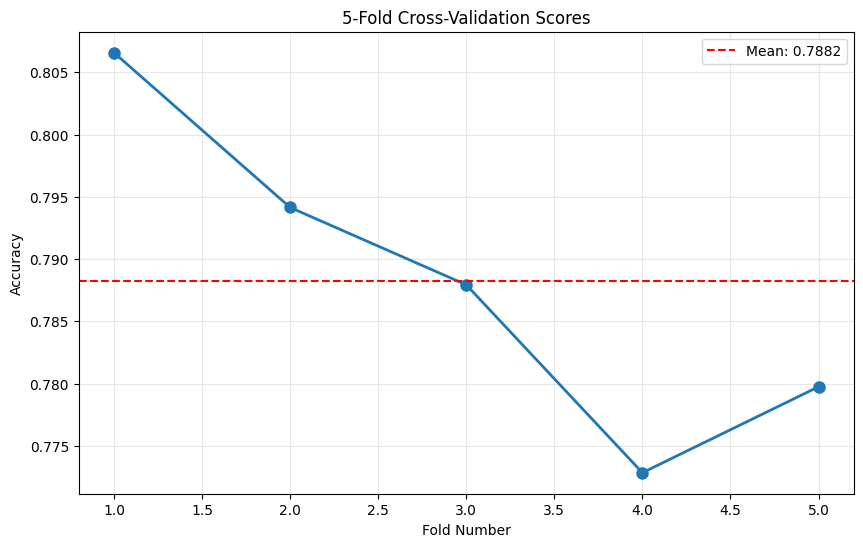

In [4]:
# Perform 5-fold cross-validation
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)
# Calculate CV scores
cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring='accuracy')
print('Cross-Validation Results:')
print(f'Scores for each fold: {cv_scores}')
print(f'Mean CV Score: {cv_scores.mean():.4f}')
print(f'Standard Deviation: {cv_scores.std():.4f}')
# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2,
markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--',
            label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Test different metrics
metrics = ['accuracy', 'precision', 'recall', 'f1']
results = {}
for metric in metrics:
    scores = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring=metric)
    results[metric] = {
    'mean': scores.mean(),
    'std': scores.std()
}
print(f'{metric.capitalize()}: {scores.mean():.4f} (+/- {scores.std():.4f})')
# Create comparison dataframe
cv_comparison = pd.DataFrame(results).T
print('\nCross-Validation Metrics Summary:')
print(cv_comparison)

F1: 0.5467 (+/- 0.0218)

Cross-Validation Metrics Summary:
               mean       std
accuracy   0.788248  0.011660
precision  0.633504  0.030964
recall     0.480936  0.016842
f1         0.546692  0.021753


In [6]:
# Define parameter grid for Random Forest
param_grid = {
'n_estimators': [100, 200, 300],
'max_depth': [10, 20, 30, None],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],
'max_features': ['sqrt', 'log2']
}
# Calculate total combinations
total_combinations = 3 * 4 * 3 * 3 * 2
print(f'Total parameter combinations: {total_combinations}')
print(f'With 5-fold CV: {total_combinations * 5} model trainings!')

Total parameter combinations: 216
With 5-fold CV: 1080 model trainings!


In [ ]:
grid_search = GridSearchCV(
estimator=RandomForestClassifier(random_state=42),
param_grid=param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1, # Use all CPU cores
verbose=2 # Show progress
)
# Fit grid search (this takes time!)
print('Starting Grid Search...')
import time
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f'\nGrid Search completed in {(end_time - start_time)/60:.2f} minutes')

Starting Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   2.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_sample

In [ ]:
print('Best Parameters:')
print(grid_search.best_params_)
print(f'\nBest Cross-Validation Score: {grid_search.best_score_:.4f}')
# Get best model
best_rf = grid_search.best_estimator_
# Evaluate on test set
y_pred_optimized = best_rf.predict(X_test)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
print(f'\nTest Set Performance:')
print(f'Baseline Accuracy: {baseline_accuracy:.4f}')
print(f'Optimized Accuracy: {optimized_accuracy:.4f}')
print(f'Improvement: {(optimized_accuracy - baseline_accuracy):.4f}')


In [ ]:
# Create XGBoost classifier
xgb_model = XGBClassifier(
n_estimators=100,
learning_rate=0.1,
max_depth=6,
random_state=42,
eval_metric='logloss' # Suppress warning
)
# Train model
xgb_model.fit(X_train, y_train)
# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {xgb_accuracy:.4f}')
print('\nXGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

In [ ]:
# XGBoost parameter grid (smaller for speed)
xgb_param_grid = {
'n_estimators': [100, 200],
'learning_rate': [0.01, 0.1, 0.3],
'max_depth': [3, 5, 7],
'subsample': [0.8, 1.0],
'colsample_bytree': [0.8, 1.0]
}
# GridSearch for XGBoost
xgb_grid = GridSearchCV(
estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
param_grid=xgb_param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1,
verbose=1
)
print('Tuning XGBoost...')
xgb_grid.fit(X_train, y_train)
# Best XGBoost model
best_xgb = xgb_grid.best_estimator_
print(f'\nBest XGBoost Parameters:')
print(xgb_grid.best_params_)
# Evaluate
y_pred_xgb_opt = best_xgb.predict(X_test)
xgb_opt_accuracy = accuracy_score(y_test, y_pred_xgb_opt)
print(f'\nOptimized XGBoost Accuracy: {xgb_opt_accuracy:.4f}')


In [ ]:
# Calculate metrics for all models
models = {
'Baseline Random Forest': (rf_baseline, y_pred_baseline),
'Optimized Random Forest': (best_rf, y_pred_optimized),
'Basic XGBoost': (xgb_model, y_pred_xgb),
'Optimized XGBoost': (best_xgb, y_pred_xgb_opt)
}
# Create comparison dataframe
comparison_data = []
for name, (model, predictions) in models.items():
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
comparison_data.append({
'Model': name,
'Accuracy': accuracy,
'Precision': precision,
'Recall': recall,
'F1-Score': f1
})
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(comparison_df.to_string(index=False))

In [ ]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_list = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for idx, metric in enumerate(metrics):
ax = axes[idx // 2, idx % 2]
ax.barh(comparison_df['Model'], comparison_df[metric], color=colors_list)
ax.set_xlabel(metric)
ax.set_title(f'{metric} Comparison')
ax.set_xlim(0.7, 0.9)
# Add value labels
for i, v in enumerate(comparison_df[metric]):
ax.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()
# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f'\n Best Model: {best_model_name} with {best_accuracy:.4f} accuracy')


In [ ]:
# Confusion matrix for best model
best_predictions = y_pred_xgb_opt # Assuming XGBoost is best
cm = confusion_matrix(y_test, best_predictions)
# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()
# Calculate specific metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives: {tp}')
print(f'\nFalse Positive Rate: {fp/(fp+tn):.4f}')
print(f'False Negative Rate: {fn/(fn+tp):.4f}')

In [ ]:
# Get feature importance from best model
if hasattr(best_xgb, 'feature_importances_'):
importances = pd.DataFrame({
'feature': X.columns,
'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)
# Plot top 15 features
plt.figure(figsize=(10, 8))
plt.barh(importances['feature'].head(15), importances['importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print('Top 10 Features:')
print(importances.head(10).to_string(index=False))


In [ ]:
# Save the best model
model_filename = 'best_churn_model.pkl'
with open(model_filename, 'wb') as file:
pickle.dump(best_xgb, file)
print(f'Model saved as {model_filename}')
# Verify we can load it
with open(model_filename, 'rb') as file:
loaded_model = pickle.load(file)
# Test loaded model
test_predictions = loaded_model.predict(X_test[:5])
print('\nTest predictions from loaded model:')
print(test_predictions)

In [ ]:
# Create metadata file
metadata = {
'model_type': 'XGBoost',
'accuracy': xgb_opt_accuracy,
'precision': precision_score(y_test, y_pred_xgb_opt),
'recall': recall_score(y_test, y_pred_xgb_opt),
'f1_score': f1_score(y_test, y_pred_xgb_opt),
'best_params': xgb_grid.best_params_,
'features': list(X.columns)
}
import json
with open('model_metadata.json', 'w') as f:
json.dump(metadata, f, indent=4)
print('Metadata saved!')


## Week 3 Summary: Model Optimization

### Key Learnings:- Cross-validation provides more reliable estimates than single train/test split- Hyperparameter tuning can improve accuracy by 2-4%- XGBoost typically outperforms other algorithms on tabular data- Feature engineering matters more than model selection
### Next Steps (Week 4):- Deploy model as interactive web application- Create user interface for predictions- Add explanation capabilities

# 📊 Customer Churn Analysis — What I Understood

## 🧠 Introduction

In this project, I worked on a **Telecom Customer Churn dataset** to understand why customers leave a telecom service. The main objective was to **predict customer churn** using machine learning models and identify key factors influencing customer decisions.

---

## 📂 Dataset Overview

- Total records: **7043 customers**
- Total features: **21 columns**
- Target variable: **Churn**

**Churn Meaning:**
- **Yes** → Customer left the service  
- **No** → Customer stayed  

---

## 🧹 Data Cleaning

During preprocessing, I found that:

- The **TotalCharges** column had missing or blank values.
- These values were converted into numeric format.
- Missing values were handled using the **median**.

✅ After cleaning, the dataset had **no missing values**.

---

## ⚙️ Data Preprocessing

To prepare data for machine learning:

### 🔹 Encoding
- Categorical variables were converted using **One-Hot Encoding**.
- Columns increased from **21 → 32**.

### 🔹 Target Conversion
- Churn was converted into binary:
  - **0 = No churn**
  - **1 = Churn**

### 🔹 Data Imbalance
- **73.46%** customers stayed  
- **26.54%** customers churned  

This shows a **slight imbalance** in the dataset.

---

## 🎯 Feature Selection

- The **customerID** column was removed (not useful for prediction).
- Final dataset:
  - **Features (X)**
  - **Target (y)**

---

## 🔀 Train-Test Split

- Training data: **80%**
- Testing data: **20%**

This helps evaluate model performance on unseen data.

---

## 🤖 Machine Learning Models

### 1. Logistic Regression
- Accuracy: **80.34%**
- Good baseline model
- Missed some churn cases

---

### 2. Decision Tree
- Accuracy: **79.42%**
- Provided feature importance

**Important features:**
- Tenure  
- Internet Service (Fiber optic)  
- Total Charges  
- Payment Method  
- Monthly Charges  

---

### 3. Random Forest
- Accuracy: **80.70%**
- Best performing model
- More stable and accurate

---

## 📈 Model Comparison

| Model | Accuracy |
|------|---------|
| Random Forest | **80.70%** |
| Logistic Regression | 80.34% |
| Decision Tree | 79.42% |

✅ **Best Model: Random Forest**

---

## 🔍 Key Insights

- Customers with **low tenure** are more likely to churn  
- **Fiber optic users** have higher churn rate  
- **Month-to-month contracts** increase churn risk  
- **Electronic check payment** users churn more  
- High **monthly charges** increase churn probability  

---

## 🏁 Conclusion

From this project, I understood that:

- Machine learning can effectively **predict customer churn**
- **Random Forest** provides the best results among tested models
- Customer behavior depends heavily on:
  - Tenure  
  - Pricing  
  - Service type  
  - Contract type  

